import and setup

In [14]:
import jax
import jax.numpy as jnp
import jax.random as random
from jax import vmap, jit, grad
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import optax
from flax import linen as nn
from flax.training import train_state
from tqdm import trange
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
jax.config.update('jax_enable_x64', True)

print("JAX version:", jax.__version__)
print("Available devices:", jax.devices())

JAX version: 0.6.2
Available devices: [CpuDevice(id=0)]


diffusion model setup

In [16]:
# Diffusion model parameters following the paper
t_0, t_1 = 0.0, 1.0
beta_0 = 0.1
beta_1 = 20.0

# Define diffusion schedules
log_alpha = lambda t: -0.5*t*beta_0-0.25*t**2*(beta_1-beta_0)
log_sigma = lambda t: jnp.log(t)
dlog_alphadt = jax.grad(lambda t: log_alpha(t).sum())
dlog_sigmadt = jax.grad(lambda t: log_sigma(t).sum())
gamma = lambda t: (1 + 0.5*t*beta_0 + 0.5*t**2*(beta_1-beta_0))

# Score function for 2D Gaussian
def score_model(x, t):
    """Score function ∇log q_t(x) for 2D Gaussian"""
    sigma_t = jnp.exp(log_sigma(t))
    return -x / (sigma_t**2 + 1e-8)

# Diffusion drift function
def f_schedule(x, t):
    """Base drift term f_t(x) = -dlog_alpha/dt * x"""
    return -dlog_alphadt(t) * x

reward function suite

In [33]:
# Create JIT-compiled version for specific reward functions
@jax.jit
def fkc_sde_step_center(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end):
    """JIT-compiled version for center reward function"""
    return fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, 
                       reward_function_center, grad_reward_center)

@jax.jit
def fkc_sde_step_quadrants(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end):
    """JIT-compiled version for quadrants reward function"""
    return fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, 
                       reward_function_quadrants, grad_reward_quadrants)

@jax.jit
def fkc_sde_step_ring(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end):
    """JIT-compiled version for ring reward function"""
    return fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, 
                       reward_function_ring, grad_reward_ring)

@jax.jit
def fkc_sde_step_complex(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end):
    """JIT-compiled version for complex reward function"""
    return fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, 
                       reward_function_complex, grad_reward_complex)

# Create gradient functions
grad_reward_center = grad(reward_function_center)
grad_reward_quadrants = grad(reward_function_quadrants)
grad_reward_ring = grad(reward_function_ring)
grad_reward_complex = grad(reward_function_complex)

# Vectorized versions
vmap_grad_reward_center = vmap(grad_reward_center)
vmap_grad_reward_quadrants = vmap(grad_reward_quadrants)
vmap_grad_reward_ring = vmap(grad_reward_ring)
vmap_grad_reward_complex = vmap(grad_reward_complex)

beta schedule functions

In [18]:
@jax.jit
def beta_schedule(t, T_max=1.0, beta_start=1.0, beta_end=10.0):
    """Beta schedule: increases as t goes from 1 → 0"""
    return beta_start + (beta_end - beta_start) * (1.0 - t / T_max)

@jax.jit
def dbeta_dt_schedule(t, T_max=1.0, beta_start=1.0, beta_end=10.0):
    """Time derivative of beta schedule"""
    return -(beta_end - beta_start) / T_max

fkc sde core

In [32]:
def fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, reward_func, grad_reward_func):
    """
    Faithful implementation of FKC SDE equations (29-30) from the paper
    
    Equation 29: dx_t = σ_t²(∇log q_t(x_t) + (β_t/2)∇r(x_t)) dt - f_t(x_t) dt + σ_t dW_t
    Equation 30: dw_t = (∂β_t/∂t)r(x_t) dt - ⟨β_t∇r(x_t), f_t(x_t)⟩ dt + ⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩ dt
    """
    # Get current beta and its derivative
    current_beta = beta_schedule(t, T_max, beta_start, beta_end)
    dbeta_t = dbeta_dt_schedule(t, T_max, beta_start, beta_end)
    
    # Diffusion coefficients
    sigma_t = jnp.exp(log_sigma(t))
    sigma_sq = sigma_t**2
    
    # Compute reward and gradient
    r_xt = vmap(reward_func)(x_t)  # Shape: (batch_size,)
    grad_r_xt = vmap(grad_reward_func)(x_t)  # Shape: (batch_size, 2)
    
    # Score function
    score_xt = score_model(x_t, t)  # Shape: (batch_size, 2)
    
    # Base drift
    f_xt = f_schedule(x_t, t)  # Shape: (batch_size, 2)
    
    # Equation 29: State evolution
    drift_x = sigma_sq * (score_xt + (current_beta / 2.0) * grad_r_xt) - f_xt
    rng, subkey = jax.random.split(rng)
    dW_t = jax.random.normal(subkey, x_t.shape) * jnp.sqrt(dt)
    x_next = x_t + drift_x * dt + sigma_t * dW_t
    
    # Equation 30: Weight evolution
    term1 = dbeta_t * r_xt[:, None]  # (∂β/∂t)r(x_t)
    term2 = -jnp.sum(current_beta * grad_r_xt * f_xt, axis=1, keepdims=True)  # -⟨β∇r, f⟩
    term3 = jnp.sum(current_beta * grad_r_xt * (sigma_sq / 2.0) * score_xt, axis=1, keepdims=True)  # ⟨β∇r, (σ²/2)∇log q⟩
    
    dw_t = (term1 + term2 + term3) * dt
    w_next = w_t + dw_t
    
    return rng, x_next, w_next

exploration

In [20]:
def compute_pairwise_distances(positions):
    """Compute pairwise distances between all particles"""
    distances = jnp.linalg.norm(positions[:, None, :] - positions[None, :, :], axis=2)
    return distances

def select_exploration_particles(weights, positions, k, exploration_strength=0.1):
    """Select k particles for exploration based on diversity and low weights"""
    batch_size = weights.shape[0]
    
    # Identify low-weight particles (candidates for replacement)
    weight_threshold = jnp.percentile(weights, 20)  # Bottom 20% by weight
    low_weight_mask = weights < weight_threshold
    low_weight_indices = jnp.where(low_weight_mask)[0]
    
    if len(low_weight_indices) < k:
        # If not enough low-weight particles, use lowest k weights
        sorted_indices = jnp.argsort(weights)
        low_weight_indices = sorted_indices[:k]
    
    # Compute pairwise distances
    distances = compute_pairwise_distances(positions)
    
    # For each low-weight particle, find most distant particles
    exploration_candidates = []
    for idx in low_weight_indices:
        particle_distances = distances[idx]
        distant_indices = jnp.argsort(particle_distances)[-k:]
        exploration_candidates.extend(distant_indices)
    
    # Remove duplicates and select top k unique candidates
    unique_candidates = jnp.unique(jnp.array(exploration_candidates))
    selected_indices = unique_candidates[:k]
    
    return selected_indices

def adaptive_k_schedule(t, T_max=1.0, k_max=50, k_min=0):
    """Adaptive k schedule: high exploration early, pure exploitation late"""
    if t >= 0.5:  # Exploration phase
        k = k_max - (k_max - k_max/2) * (1.0 - t) / 0.5
    else:  # Exploitation phase
        k = k_max/2 - (k_max/2 - k_min) * (0.5 - t) / 0.5
    
    return int(jnp.clip(k, k_min, k_max))

resampling

In [22]:
from scipy.stats import qmc
sampler = qmc.Sobol(d=1, scramble=False)

@partial(jax.jit, static_argnums=0)
def sample_cat_sys(bs, key, logits):
    """Systematic resampling"""
    u = jax.random.uniform(key, shape=(1,))
    u = (u + 1/bs*jnp.arange(bs)) % 1
    bins = jnp.cumsum(nn.softmax(logits))
    ids = jnp.digitize(u, bins)
    return ids, None

def exploration_resampling(weights, positions, t, T_max=1.0, k_max=50, k_min=0):
    """Enhanced resampling with exploration mechanism"""
    batch_size = weights.shape[0]
    
    # Get adaptive k
    k = adaptive_k_schedule(t, T_max, k_max, k_min)
    
    if k == 0:
        # Pure exploitation: standard resampling
        key = random.PRNGKey(42)
        new_ids, _ = sample_cat_sys(batch_size, key, weights)
        return new_ids
    
    # Exploration + Exploitation hybrid
    exploration_indices = select_exploration_particles(weights, positions, k)
    
    # Standard resampling for all particles
    key = random.PRNGKey(42)
    new_ids, _ = sample_cat_sys(batch_size, key, weights)
    
    # Replace exploration particles with diverse ones
    for i, exp_idx in enumerate(exploration_indices):
        distances = jnp.linalg.norm(positions - positions[exp_idx], axis=1)
        diverse_idx = jnp.argmax(distances)
        new_ids = new_ids.at[exp_idx].set(diverse_idx)
    
    return new_ids

generation

In [31]:
def generate_fkc_samples(key, reward_func, grad_reward_func, reward_name,
                        n_steps=1000, bs=512, dt=1e-3, T_max=1.0, 
                        beta_start=1.0, beta_end=10.0, resample=True,
                        exploration=True, k_max=50, k_min=0):
    """Generate samples using FKC with exploration"""
    print(f"Generating with reward function: {reward_name}")
    
    # Select the appropriate JIT-compiled function based on reward name
    if "Center" in reward_name:
        fkc_step_fn = fkc_sde_step_center
    elif "Quadrant" in reward_name:
        fkc_step_fn = fkc_sde_step_quadrants
    elif "Ring" in reward_name:
        fkc_step_fn = fkc_sde_step_ring
    elif "Complex" in reward_name:
        fkc_step_fn = fkc_sde_step_complex
    else:
        # Fallback to non-JIT version
        fkc_step_fn = lambda rng, x_t, w_t, t, dt, T_max, beta_start, beta_end: fkc_sde_step(
            rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, reward_func, grad_reward_func
        )
    
    # Initialize generation arrays
    key, ikey = random.split(key, num=2)
    x_gen = jnp.zeros((bs, n_steps + 1, 2))
    w_gen = jnp.zeros((bs, n_steps + 1, 1))

    # Initialize with noise (starting from t=1, going to t=0)
    x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, 2)))
    w_gen = w_gen.at[:, 0, :].set(0.0)

    # Time starts at t=1 and goes to t=0
    t = T_max

    for i in trange(n_steps, desc=f'FKC generation ({reward_name})'):
        key, *ikey = random.split(key, num=3)
        
        # Perform one step of FKC SDE
        key, x_next, w_next = fkc_step_fn(
            key, x_gen[:, i, :], w_gen[:, i, :], t, dt, T_max, 
            beta_start, beta_end
        )
        
        # Update arrays
        x_gen = x_gen.at[:, i+1, :].set(x_next)
        w_gen = w_gen.at[:, i+1, :].set(w_next)
        
        # Enhanced resampling with exploration
        if resample and i % 20 == 0:
            if exploration:
                new_ids = exploration_resampling(
                    w_gen[:, i+1, 0], x_gen[:, i+1, :], t, T_max, k_max, k_min
                )
            else:
                new_ids, _ = sample_cat_sys(bs, ikey[1], w_gen[:, i+1, 0])
            
            x_gen = x_gen.at[:, i+1, :].set(x_gen[new_ids, i+1, :])
            w_gen = w_gen.at[:, i+1, :].set(0.0)
        
        t -= dt
    
    return key, x_gen, w_gen

neural network

In [24]:
class RewardNetwork(nn.Module):
    """Neural network to learn reward functions from particle samples"""
    
    @nn.compact
    def __call__(self, x):
        # Input: x shape (batch_size, 2) - particle positions
        # Output: reward values for each particle
        
        # First hidden layer
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        
        # Second hidden layer
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        
        # Third hidden layer
        x = nn.Dense(64)(x)
        x = nn.relu(x)
        
        # Fourth hidden layer
        x = nn.Dense(32)(x)
        x = nn.relu(x)
        
        # Output layer - single reward value per particle
        reward = nn.Dense(1)(x)
        
        return reward.squeeze(-1)  # Remove last dimension to get shape (batch_size,)

def create_network():
    """Create and initialize the reward network"""
    network = RewardNetwork()
    key = random.PRNGKey(42)
    
    # Initialize with dummy input
    dummy_input = jnp.ones((1, 2))  # Single particle at (1,1)
    params = network.init(key, dummy_input)
    
    return network, params

# Test the network
network, params = create_network()

adversarial training

In [39]:
def generate_training_data(key, reward_func, grad_reward_func, reward_name,
                          num_temperatures=5, samples_per_temp=1000):
    """Generate training data at multiple temperatures"""
    print(f"Generating training data for {reward_name}")
    
    all_samples = []
    all_rewards = []
    all_temperatures = []
    
    # Sample at different temperatures
    beta_values = jnp.linspace(1.0, 10.0, num_temperatures)
    
    for beta_val in beta_values:
        key, x_gen, w_gen = generate_fkc_samples(
            key, reward_func, grad_reward_func, f"{reward_name}_beta_{beta_val:.1f}",
            n_steps=500, bs=samples_per_temp, dt=1e-3, T_max=1.0,
            beta_start=beta_val, beta_end=beta_val, resample=True,
            exploration=True, k_max=50, k_min=0
        )
        
        # Get final samples and their rewards
        final_samples = x_gen[:, -1, :]  # Shape: (samples_per_temp, 2)
        final_rewards = vmap(reward_func)(final_samples)  # Shape: (samples_per_temp,)
        
        all_samples.append(final_samples)
        all_rewards.append(final_rewards)
        all_temperatures.extend([beta_val] * samples_per_temp)
    
    # Concatenate all data
    all_samples = jnp.concatenate(all_samples, axis=0)  # Shape: (num_temperatures * samples_per_temp, 2)
    all_rewards = jnp.concatenate(all_rewards, axis=0)  # Shape: (num_temperatures * samples_per_temp,)
    all_temperatures = jnp.array(all_temperatures)  # Shape: (num_temperatures * samples_per_temp,)
    
    return key, all_samples, all_rewards, all_temperatures

def adversarial_loss(params, samples, true_rewards, network):
    """Adversarial loss: network learns to approximate true rewards"""
    predicted_rewards = network.apply(params, samples)
    loss = jnp.mean((predicted_rewards - true_rewards)**2)
    return loss

# Remove JIT compilation to avoid issues
def train_step(params, samples, true_rewards, network, optimizer, opt_state):
    """Single training step - no JIT compilation"""
    loss_fn = lambda p: adversarial_loss(p, samples, true_rewards, network)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, loss, new_opt_state

training loop

In [46]:
def train_reward_network(key, reward_func, grad_reward_func, reward_name,
                        num_epochs=100, batch_size=256, learning_rate=1e-3):
    """Train the reward network using adversarial training"""
    print(f"Training reward network for {reward_name}")
    
    # Generate training data
    key, samples, true_rewards, temperatures = generate_training_data(
        key, reward_func, grad_reward_func, reward_name,
        num_temperatures=5, samples_per_temp=1000
    )
    
    # Create network and optimizer
    network, params = create_network()
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    # Training loop
    losses = []
    num_batches = len(samples) // batch_size
    
    for epoch in trange(num_epochs, desc="Training"):
        epoch_losses = []
        
        # Shuffle data
        key, shuffle_key = random.split(key)
        indices = random.permutation(shuffle_key, len(samples))
        shuffled_samples = samples[indices]
        shuffled_rewards = true_rewards[indices]
        
        # Mini-batch training
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            
            batch_samples = shuffled_samples[start_idx:end_idx]
            batch_rewards = shuffled_rewards[start_idx:end_idx]
            
            # Training step - pass all required arguments
            params, loss, opt_state = train_step(params, batch_samples, batch_rewards, network, optimizer, opt_state)
            epoch_losses.append(loss)
        
        avg_loss = jnp.mean(jnp.array(epoch_losses))
        losses.append(avg_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    # Return key as the first value to match expected unpacking
    return key, network, params, losses, samples, true_rewards

evaluation

In [45]:
def evaluate_network(network, params, reward_func, reward_name, 
                    x_range=(-3, 3), y_range=(-3, 3), resolution=100):
    """Evaluate network performance by comparing with true reward function"""
    # Create grid
    x = jnp.linspace(x_range[0], x_range[1], resolution)
    y = jnp.linspace(y_range[0], y_range[1], resolution)
    X, Y = jnp.meshgrid(x, y)
    points = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    
    # Get predictions
    predicted_rewards = network.apply(params, points)
    true_rewards = vmap(reward_func)(points)
    
    # Reshape for plotting
    pred_grid = predicted_rewards.reshape(resolution, resolution)
    true_grid = true_rewards.reshape(resolution, resolution)
    
    # Compute error
    mse = jnp.mean((predicted_rewards - true_rewards)**2)
    mae = jnp.mean(jnp.abs(predicted_rewards - true_rewards))
    
    print(f"Evaluation for {reward_name}:")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")
    
    return pred_grid, true_grid, mse, mae

def plot_comparison(pred_grid, true_grid, reward_name, x_range=(-3, 3), y_range=(-3, 3)):
    """Plot comparison between predicted and true rewards"""
    x = jnp.linspace(x_range[0], x_range[1], pred_grid.shape[0])
    y = jnp.linspace(y_range[0], y_range[1], pred_grid.shape[1])
    X, Y = jnp.meshgrid(x, y)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Predicted rewards
    im1 = ax1.contourf(X, Y, pred_grid, levels=20, cmap='viridis')
    ax1.set_title(f'Predicted Rewards: {reward_name}')
    ax1.set_xlabel('x1')
    ax1.set_ylabel('x2')
    plt.colorbar(im1, ax=ax1)
    
    # True rewards
    im2 = ax2.contourf(X, Y, true_grid, levels=20, cmap='viridis')
    ax2.set_title(f'True Rewards: {reward_name}')
    ax2.set_xlabel('x1')
    ax2.set_ylabel('x2')
    plt.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

main


Training for Center (Origin)
Training reward network for Center (Origin)
Generating training data for Center (Origin)
Generating with reward function: Center (Origin)_beta_1.0


FKC generation (Center (Origin)_beta_1.0): 100%|██████████| 500/500 [00:13<00:00, 38.26it/s]


Generating with reward function: Center (Origin)_beta_3.2


FKC generation (Center (Origin)_beta_3.2): 100%|██████████| 500/500 [00:11<00:00, 42.04it/s]


Generating with reward function: Center (Origin)_beta_5.5


...

Epoch 30, Loss: 0.000048


Training:  82%|████████▏ | 41/50 [00:31<00:07,  1.27it/s]

Epoch 40, Loss: 0.000035


Training: 100%|██████████| 50/50 [00:38<00:00,  1.28it/s]


Evaluation for Center (Origin):
MSE: 86995.013473
MAE: 242.017376


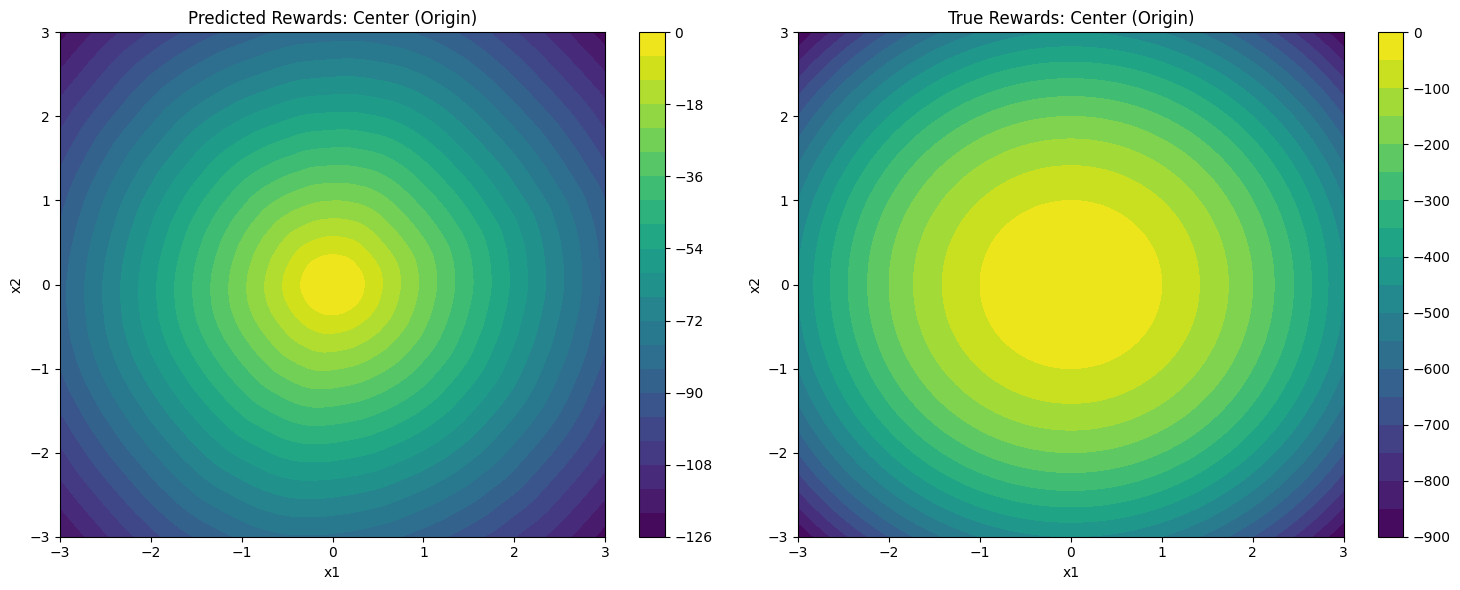


Training for Quadrant Points
Training reward network for Quadrant Points
Generating training data for Quadrant Points
Generating with reward function: Quadrant Points_beta_1.0


FKC generation (Quadrant Points_beta_1.0): 100%|██████████| 500/500 [00:18<00:00, 26.77it/s]


Generating with reward function: Quadrant Points_beta_3.2


FKC generation (Quadrant Points_beta_3.2): 100%|██████████| 500/500 [00:15<00:00, 32.12it/s]


Generating with reward function: Quadrant Points_beta_5.5


...

Epoch 30, Loss: 0.322572


Training:  82%|████████▏ | 41/50 [00:31<00:06,  1.34it/s]

Epoch 40, Loss: 0.320385


Training: 100%|██████████| 50/50 [00:37<00:00,  1.32it/s]


Evaluation for Quadrant Points:
MSE: 1253.753548
MAE: 30.202157


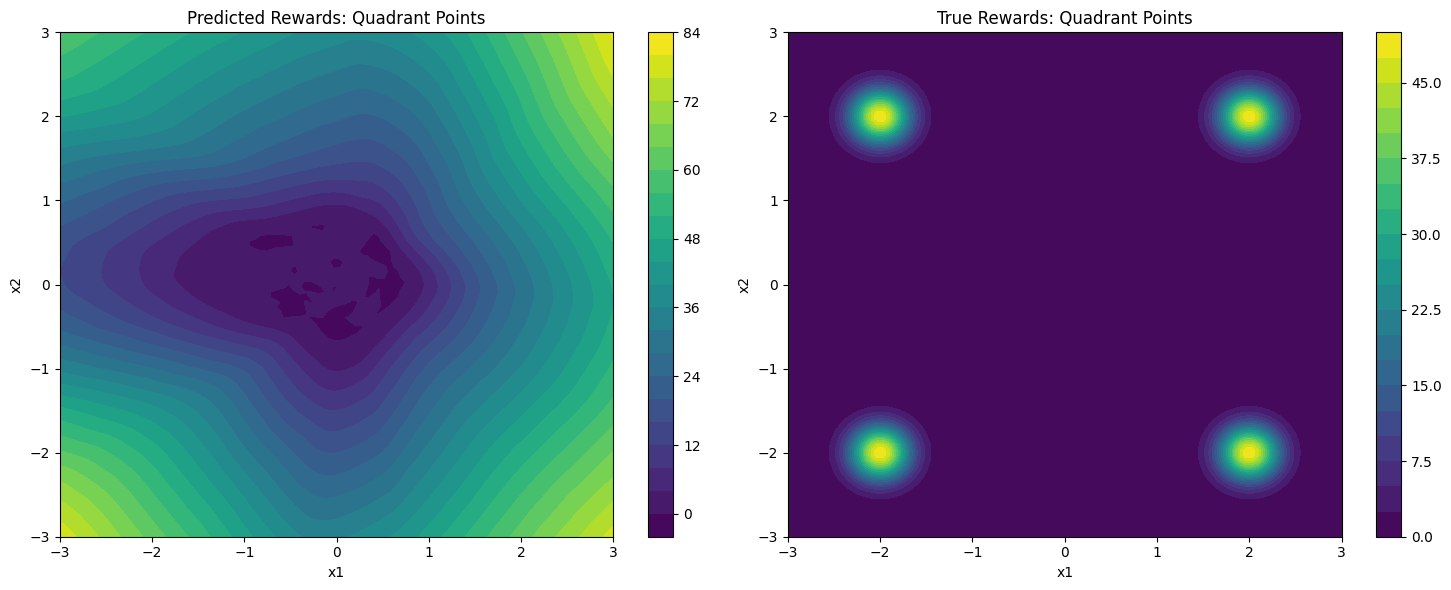


Training for Circular Ring
Training reward network for Circular Ring
Generating training data for Circular Ring
Generating with reward function: Circular Ring_beta_1.0


FKC generation (Circular Ring_beta_1.0): 100%|██████████| 500/500 [00:14<00:00, 33.34it/s]


Generating with reward function: Circular Ring_beta_3.2


FKC generation (Circular Ring_beta_3.2): 100%|██████████| 500/500 [00:13<00:00, 37.43it/s]


Generating with reward function: Circular Ring_beta_5.5


...

Epoch 30, Loss: 3.292352


Training:  82%|████████▏ | 41/50 [00:30<00:06,  1.36it/s]

Epoch 40, Loss: 0.693786


Training: 100%|██████████| 50/50 [00:37<00:00,  1.35it/s]


Evaluation for Circular Ring:
MSE: 3445.729958
MAE: 37.890892


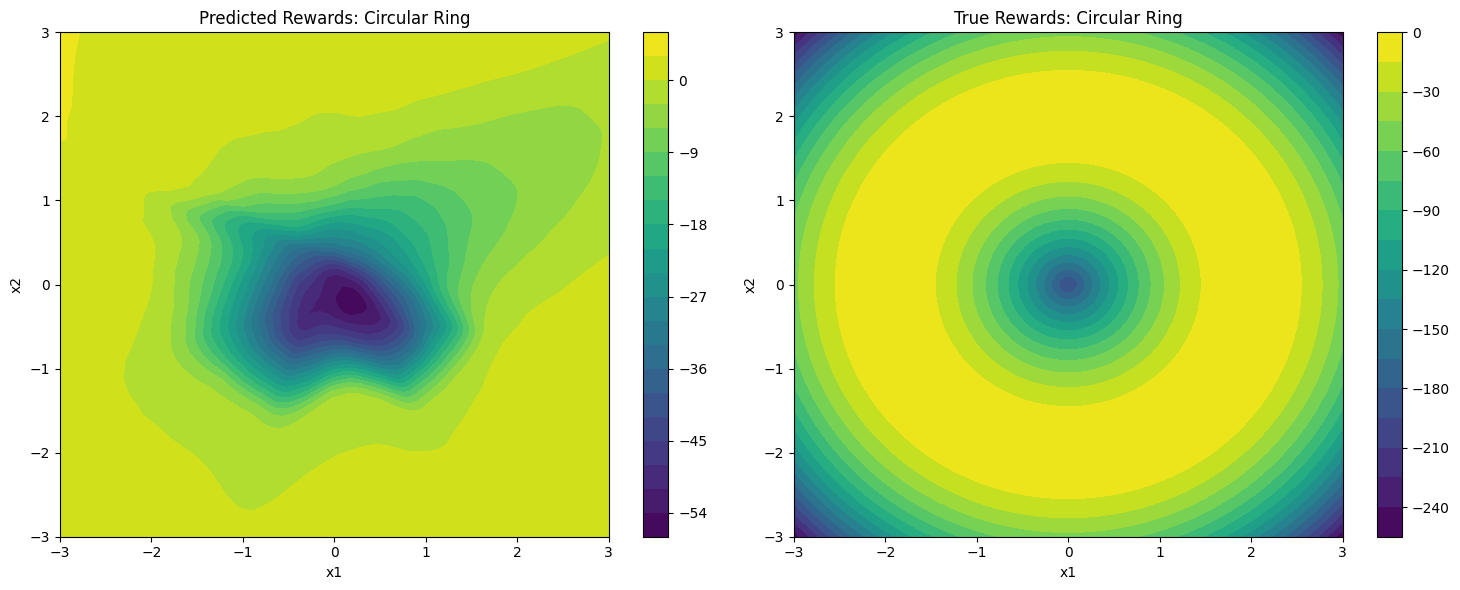


Training for Complex Landscape
Training reward network for Complex Landscape
Generating training data for Complex Landscape
Generating with reward function: Complex Landscape_beta_1.0


FKC generation (Complex Landscape_beta_1.0): 100%|██████████| 500/500 [00:13<00:00, 36.95it/s]


Generating with reward function: Complex Landscape_beta_3.2


FKC generation (Complex Landscape_beta_3.2): 100%|██████████| 500/500 [00:12<00:00, 39.52it/s]


Generating with reward function: Complex Landscape_beta_5.5


...

Epoch 30, Loss: 0.022290


Training:  82%|████████▏ | 41/50 [00:29<00:06,  1.36it/s]

Epoch 40, Loss: 0.034100


Training: 100%|██████████| 50/50 [00:36<00:00,  1.37it/s]


Evaluation for Complex Landscape:
MSE: 997.055575
MAE: 25.802835


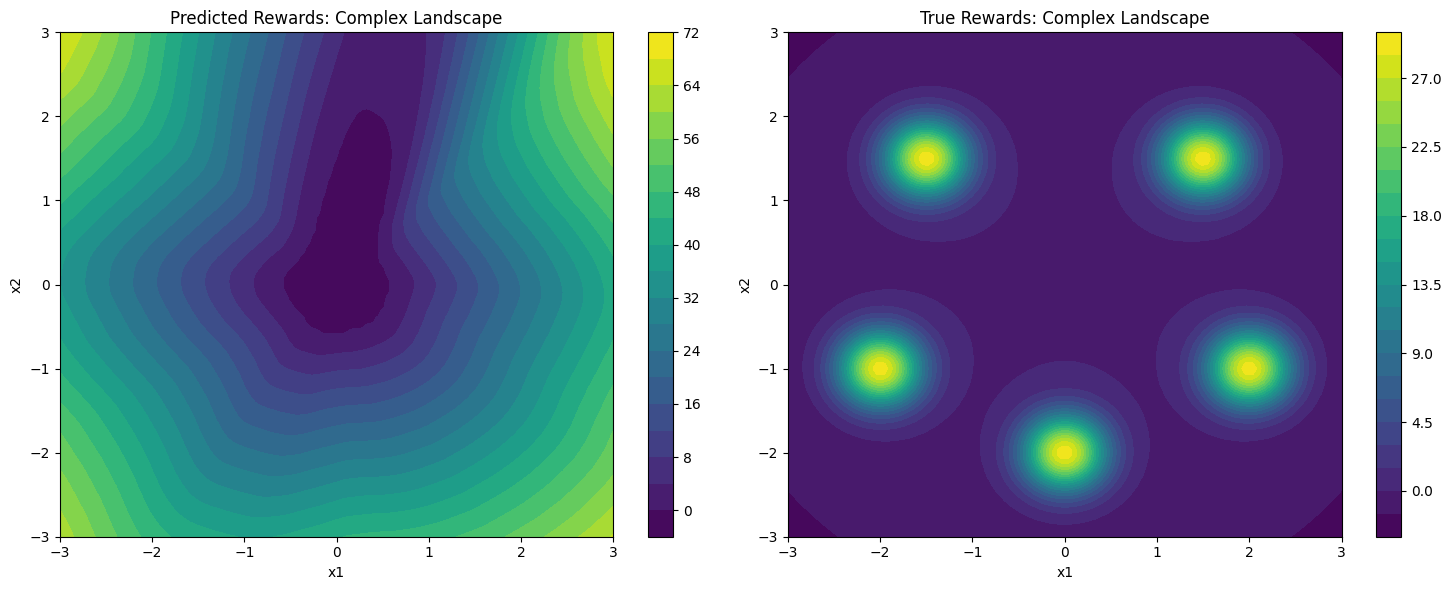

In [47]:
# Define reward functions and their names
reward_functions = [
    reward_function_center,
    reward_function_quadrants,
    reward_function_ring,
    reward_function_complex
]

reward_names = [
    "Center (Origin)",
    "Quadrant Points",
    "Circular Ring",
    "Complex Landscape"
]

grad_functions = [
    vmap_grad_reward_center,
    vmap_grad_reward_quadrants,
    vmap_grad_reward_ring,
    vmap_grad_reward_complex
]

# Train networks for each reward function
trained_networks = {}
key = random.PRNGKey(42)

for reward_func, reward_name, grad_func in zip(reward_functions, reward_names, grad_functions):
    print(f"\n{'='*50}")
    print(f"Training for {reward_name}")
    print(f"{'='*50}")
    
    key, network, params, losses, samples, true_rewards = train_reward_network(
        key, reward_func, grad_func, reward_name,
        num_epochs=50, batch_size=256, learning_rate=1e-3
    )
    
    # Evaluate network
    pred_grid, true_grid, mse, mae = evaluate_network(
        network, params, reward_func, reward_name
    )
    
    # Plot comparison
    plot_comparison(pred_grid, true_grid, reward_name)
    
    # Store results
    trained_networks[reward_name] = {
        'network': network,
        'params': params,
        'losses': losses,
        'mse': mse,
        'mae': mae
    }